# E-Commerce Sales Analysis

## Objective

Analyse customer transactions to identify:

- Revenue trends
- Top-performing products
- Most valuable customers
- Geographic sales patterns
- Opportunities for business growth

In [5]:
import matplotlib
import pandas as pd

df = pd.read_csv(
    "../data/processed/cleaned_data.csv",
    parse_dates=["InvoiceDate"]
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,December
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,December
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,December
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,December
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,December


In [6]:
total_revenue = df["Revenue"].sum()
total_orders = df["InvoiceNo"].nunique()
total_customers = df["CustomerID"].nunique()

average_order_value = (
    total_revenue / total_orders
)

print(f"Revenue: £{total_revenue:,.2f}")
print(f"Orders: {total_orders:,}")
print(f"Customers: {total_customers:,}")
print(f"Average Order Value: £{average_order_value:,.2f}")

Revenue: £8,887,208.89
Orders: 18,532
Customers: 4,338
Average Order Value: £479.56


<Axes: xlabel='InvoiceDate'>

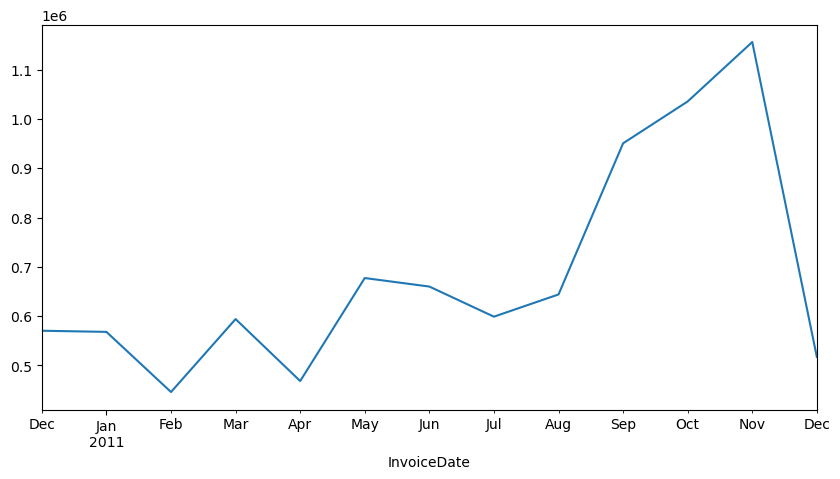

In [7]:
monthly_revenue = (
    df.groupby(
        df["InvoiceDate"].dt.to_period("M")
    )["Revenue"]
    .sum()
)

monthly_revenue.plot(figsize=(10,5))

In [17]:
top_products = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

#top_products.plot(kind="bar")

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: Revenue, dtype: float64

<Axes: xlabel='Description'>

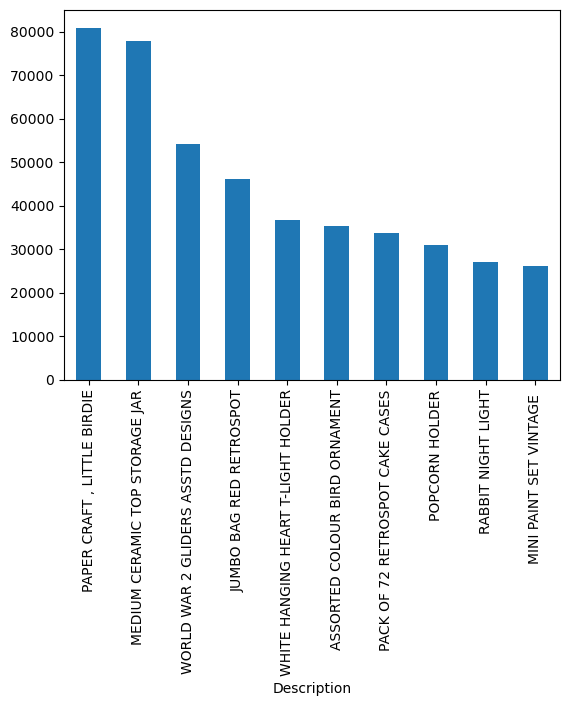

In [15]:
top_quantity = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_quantity

top_quantity.plot(kind="bar")

In [20]:
top_customers = (
    df.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

(sum(top_customers)/total_revenue)*100

#top_customers.plot(kind="bar")

np.float64(17.301936168487227)

<Axes: xlabel='Country'>

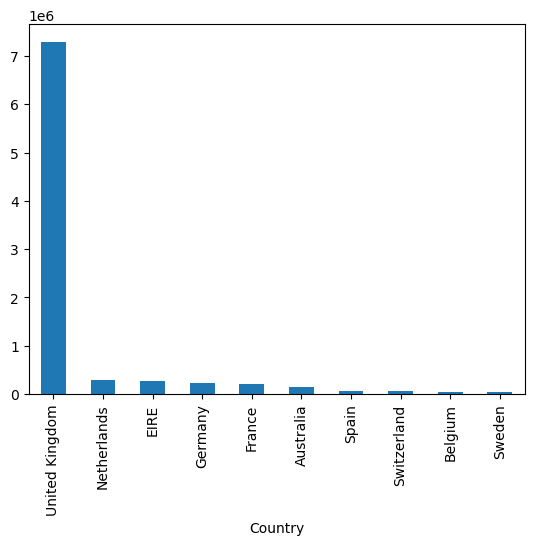

In [11]:
country_revenue = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_revenue

country_revenue.plot(kind="bar")

In [12]:
orders_per_customer = (
    df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
)

orders_per_customer.describe()

count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: InvoiceNo, dtype: float64

<Axes: >

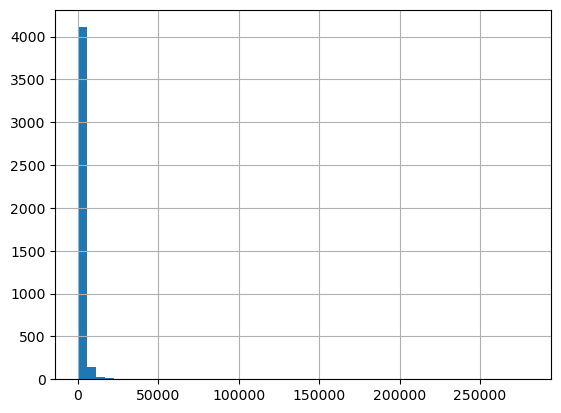

In [16]:
customer_revenue = (
    df.groupby("CustomerID")["Revenue"]
    .sum()
)

customer_revenue.hist(bins=50)

# Key Findings

1. Total revenue was £8,887,208.89
2. Revenue peaked in November
3. The paper craft little birdie generated the highest revenue.
4. The top 10 customers contributed 17.3% of sales.
5. The UK generated the majority of revenue.
6. Revenue is concentrated among a relatively small customer segment.